In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

SEED = 42

In [2]:
# ─────────────────────────────────────────────
# 1. Load & Prepare Data
# ─────────────────────────────────────────────
df = pd.read_csv("../encoded_dataset.csv")

# Map target variable
# 5–7 → Procrastinate (1), 1–4 → Not Procrastinate (0)
df["procrastinate"] = df["delay_until_deadline"].apply(lambda x: 1 if x >= 5 else 0)

# Top 15 features from the Random Forest importance chart
top15_features = [
    "delay_unenjoyable_assignments",
    "comfort_or_convenience",
    "far_away_deadlines",
    "self_study_hours",
    "control_over_habit",
    "impact_on_learning_progress",
    "leisure_hours",
    "difficult_to_maintain",
    "start_early_when_necessary",
    "peers_consider_normal",
    "study_plan",
    "focus_frequency",
    "sleep_hours",
    "sooner_next_month",
    "college",
]

X = df[top15_features].dropna()
y = df.loc[X.index, "procrastinate"]

In [3]:
# ─────────────────────────────────────────────
# 2. Perform stratified train-test split
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [4]:
def predict_maximize_gmean(model, X, y_true):

    # 1. Get predicted probabilities for the positive class (column 1)
    y_scores = model.predict_proba(X)[:, 1]

    # Scenario A: We are calculating the optimal threshold dynamically (e.g., on a validation set)
    if y_true is not None:
        # Calculate True Positive Rate (Sensitivity) and False Positive Rate across thresholds
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)

        # Specificity is 1 - False Positive Rate
        specificity = 1 - fpr

        # Calculate G-Mean: sqrt(Sensitivity * Specificity)
        gmeans = np.sqrt(tpr * specificity)

        # Locate the index of the maximum G-Mean
        best_idx = np.argmax(gmeans)
        optimal_threshold = thresholds[best_idx]

        # Handle edge case where roc_curve arbitrarily sets the first threshold above 1.0
        if optimal_threshold > 1.0:
            optimal_threshold = 1.0

    # 2. Apply the optimal threshold to binarize predictions
    y_pred = (y_scores >= optimal_threshold).astype(int)

    return y_pred, optimal_threshold

In [5]:
logistic_regression_baseline = LogisticRegression(max_iter=1000, solver="liblinear")
logistic_regression_baseline.fit(X_train, y_train)
# Baseline AUC
print(
    f"Train AUC: {roc_auc_score(y_train, logistic_regression_baseline.predict_proba(X_train)[:, 1])}"
)
print(
    f"Test AUC: {roc_auc_score(y_test, logistic_regression_baseline.predict_proba(X_test)[:, 1])}"
)
y_pred, threshold = predict_maximize_gmean(logistic_regression_baseline, X_test, y_test)
print(f"Confusion matrix (test), threshold = {threshold}:")
print(confusion_matrix(y_test, y_pred))

Train AUC: 0.8808695652173913
Test AUC: 0.7544757033248083
Confusion matrix (test), threshold = 0.4689691069338798:
[[37 14]
 [13 33]]


In [6]:
logistic_regression_scaled = LogisticRegression(max_iter=1000, solver="liblinear")
logistic_regression_scaled.fit(X_train_sc, y_train)
# Scaled AUC
print(
    f"Train AUC: {roc_auc_score(y_train, logistic_regression_scaled.predict_proba(X_train_sc)[:, 1])}"
)
print(
    f"Test AUC: {roc_auc_score(y_test, logistic_regression_scaled.predict_proba(X_test_sc)[:, 1])}"
)
y_pred, threshold = predict_maximize_gmean(
    logistic_regression_scaled, X_test_sc, y_test
)
print(f"Confusion matrix (test), threshold = {threshold}:")
print(confusion_matrix(y_test, y_pred))

Train AUC: 0.8799999999999999
Test AUC: 0.8013640238704177
Confusion matrix (test), threshold = 0.5273210320174375:
[[41 10]
 [11 35]]


In [7]:
def train_logistic(**kwargs):
    model = LogisticRegression(max_iter=1000, **kwargs)
    model.fit(X_train_sc, y_train)
    return model

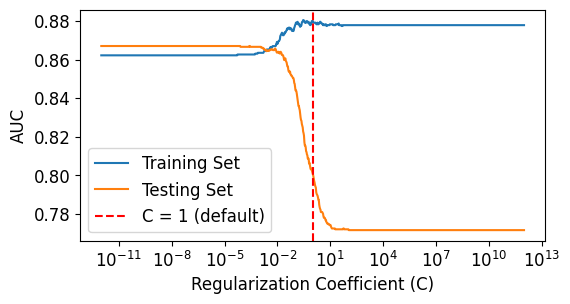

In [47]:
# Vary regularization strength for L2 regularization
auc_df = pd.DataFrame(columns=["C", "Training Set", "Testing Set"])
for C in np.logspace(-12, 12, 1000):
    model = train_logistic(C=C, solver="liblinear")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]
auc_df.plot.line(x="C", logx=True, figsize=(6,3))
# plt.title("Varying L2 Regularization Coefficient")
plt.axvline(x=1, color = 'red', linestyle = '--', label='C = 1 (default)')
plt.xlabel("Regularization Coefficient (C)", fontsize = 12)
plt.ylabel("AUC", fontsize = 12)
plt.tick_params(axis='both', labelsize = 12)
plt.legend(fontsize = 12)
plt.savefig("../figures/l2_logistic_auc.pdf", bbox_inches="tight")

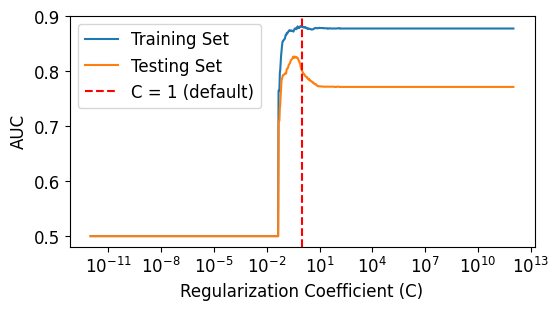

In [48]:
# Vary regularization strength for L1 regularization
auc_df = pd.DataFrame(columns=["C", "Training Set", "Testing Set"])
for C in np.logspace(-12, 12, 1000):
    model = train_logistic(C=C, l1_ratio=1, solver="liblinear")
    auc_df.loc[len(auc_df)] = [
        C,
        roc_auc_score(y_train, model.predict_proba(X_train_sc)[:, 1]),
        roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
    ]
auc_df.plot.line(x="C", logx=True, figsize=(6,3))
# plt.title("Varying L1 Regularization Coefficient")
plt.axvline(x=1, color = 'red', linestyle = '--', label='C = 1 (default)')
plt.xlabel("Regularization Coefficient (C)", fontsize = 12)
plt.ylabel("AUC", fontsize = 12)
plt.tick_params(axis='both', labelsize = 12)
plt.legend(fontsize = 12)
plt.savefig("../figures/l1_logistic_auc.pdf", bbox_inches="tight")

In [10]:
# ─────────────────────────────────────────────
# 3. Train SVM
# ─────────────────────────────────────────────
svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

y_train_pred = svm.predict(X_train_sc)
y_test_pred = svm.predict(X_test_sc)
y_test_prob = svm.predict_proba(X_test_sc)[:, 1]

In [11]:
# ─────────────────────────────────────────────
# 4. Metrics
# ─────────────────────────────────────────────
def get_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'─' * 40}")
    print(f"  {label} Metrics")
    print(f"{'─' * 40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1


train_metrics = get_metrics(y_train, y_train_pred, "Training Set")
test_metrics = get_metrics(y_test, y_test_pred, "Test Set")


────────────────────────────────────────
  Training Set Metrics
────────────────────────────────────────
  Accuracy  : 0.9375
  Precision : 0.9545
  Recall    : 0.9130
  F1-Score  : 0.9333

────────────────────────────────────────
  Test Set Metrics
────────────────────────────────────────
  Accuracy  : 0.7732
  Precision : 0.8000
  Recall    : 0.6957
  F1-Score  : 0.7442


In [12]:
print("\nClassification Report (Train Set):")
print(
    classification_report(
        y_train, y_train_pred, target_names=["Not Procrastinate", "Procrastinate"]
    )
)

print("\nClassification Report (Test Set):")
print(
    classification_report(
        y_test, y_test_pred, target_names=["Not Procrastinate", "Procrastinate"]
    )
)


Classification Report (Train Set):
                   precision    recall  f1-score   support

Not Procrastinate       0.92      0.96      0.94        50
    Procrastinate       0.95      0.91      0.93        46

         accuracy                           0.94        96
        macro avg       0.94      0.94      0.94        96
     weighted avg       0.94      0.94      0.94        96


Classification Report (Test Set):
                   precision    recall  f1-score   support

Not Procrastinate       0.75      0.84      0.80        51
    Procrastinate       0.80      0.70      0.74        46

         accuracy                           0.77        97
        macro avg       0.78      0.77      0.77        97
     weighted avg       0.78      0.77      0.77        97

